# PyTorch Custom Datasets

In [1]:
import torch
from torch import nn

In [2]:
torch.__version__

'2.10.0+cu128'

In [3]:
import os

class Config:
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Device Agnostic Code
  batch_size = 32
  num_workers = os.cpu_count()
  num_color_channels = 3

## 1. Get Data

In [4]:
import requests
import zipfile
from pathlib import Path

data_path = Path("data")
images_path = data_path / "pizza_steak_sushi_images"
zipfile_path = data_path / "pizza_steak_sushi.zip"

if not images_path.is_dir():
  images_path.mkdir(parents=True, exist_ok=True)

with open(zipfile_path, "wb") as f:
  response = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/data/pizza_steak_sushi.zip")
  f.write(response.content)

with zipfile.ZipFile(zipfile_path, "r") as zip_ref:
  zip_ref.extractall(images_path)

## 2. Data Preparation and Exploration

In [5]:
train_path = images_path / "train"
test_path = images_path / "test"

train_path, test_path

(PosixPath('data/pizza_steak_sushi_images/train'),
 PosixPath('data/pizza_steak_sushi_images/test'))

### 2.1 Visualizing an Image

Image class: sushi | Height: 512 | Width: 512


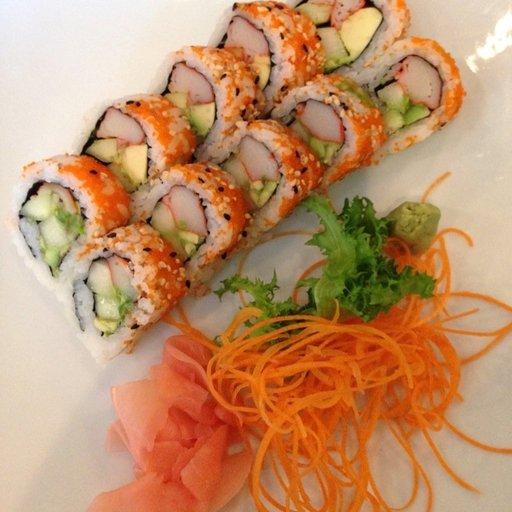

In [6]:
import random
from PIL import Image

# Get all image paths
image_path_list = list(images_path.glob("*/*/*.jpg"))

# Get a random path
random_image_path = random.choice(image_path_list)

# Get the image class (the name of the directory where it is stored)
image_class = random_image_path.parent.stem

image = Image.open(random_image_path)

print(f"Image class: {image_class} | Height: {image.height} | Width: {image.width}")
image

### 2.2 - Visualizing the Image using matplotlib

Text(0.5, 1.0, 'Image Shape: (512, 512, 3) -> [height, width, color_channels]')

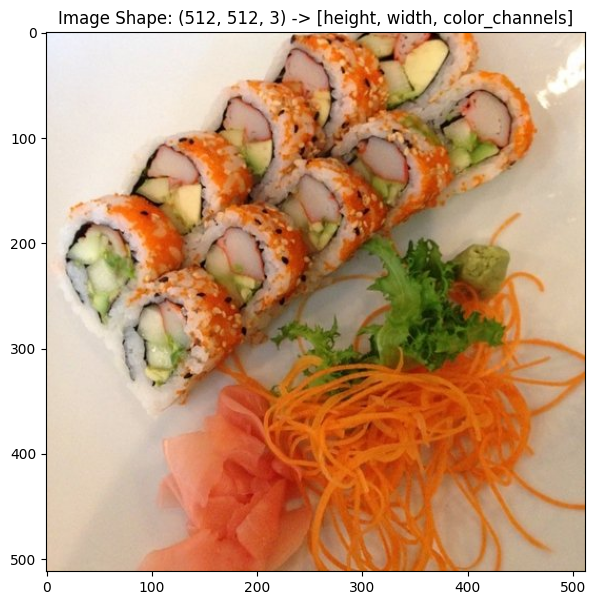

In [7]:
import matplotlib.pyplot as plt
import numpy as np

img_as_array = np.asarray(image)

plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image Shape: {img_as_array.shape} -> [height, width, color_channels]")

## 3. Transforming Data to Tensors

In [8]:
from torchvision import transforms

# Defining our transform
img_transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize to fixed spatial dims
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(), # PIL → tensor + scales [0,255] to [0.0,1.0]
])

### 3.1 - Visualizing our transformed images

In [9]:
transformed_image = img_transform(image)

transformed_image.unsqueeze(dim=0).shape

torch.Size([1, 3, 224, 224])

In [10]:
def create_image_dict(image_path):
  img = Image.open(image_path)
  label = image_path.parent.stem

  return  {
    "pil_image": img,
    "label": label
  }


def plot_transformed_images(images_path, transform, n=3):
  random_images_list = []
  for i in range(n):
    random_image_path = random.choice(images_path)
    image_dict = create_image_dict(random_image_path)
    random_images_list.append(image_dict)

  image_tensors = [transform(img_obj["pil_image"]) for img_obj in random_images_list]
  image_pil = [img_obj["pil_image"] for img_obj in random_images_list]
  image_labels = [img_obj["label"] for img_obj in random_images_list]

  fig, axes = plt.subplots(n, 2, figsize=(12, 10))

  for idx, image_tensor in enumerate(image_tensors):
    # Original
    axes[idx][0].imshow(image_pil[idx])
    axes[idx][0].axis("off")
    axes[idx][0].set_title("Original: " + image_labels[idx])

    # Transformed
    display_image = image_tensor.permute(1, 2, 0)
    axes[idx][1].imshow(display_image)
    axes[idx][1].axis("off")
    axes[idx][1].set_title("Transformed: " + image_labels[idx])

  plt.tight_layout()
  plt.show()


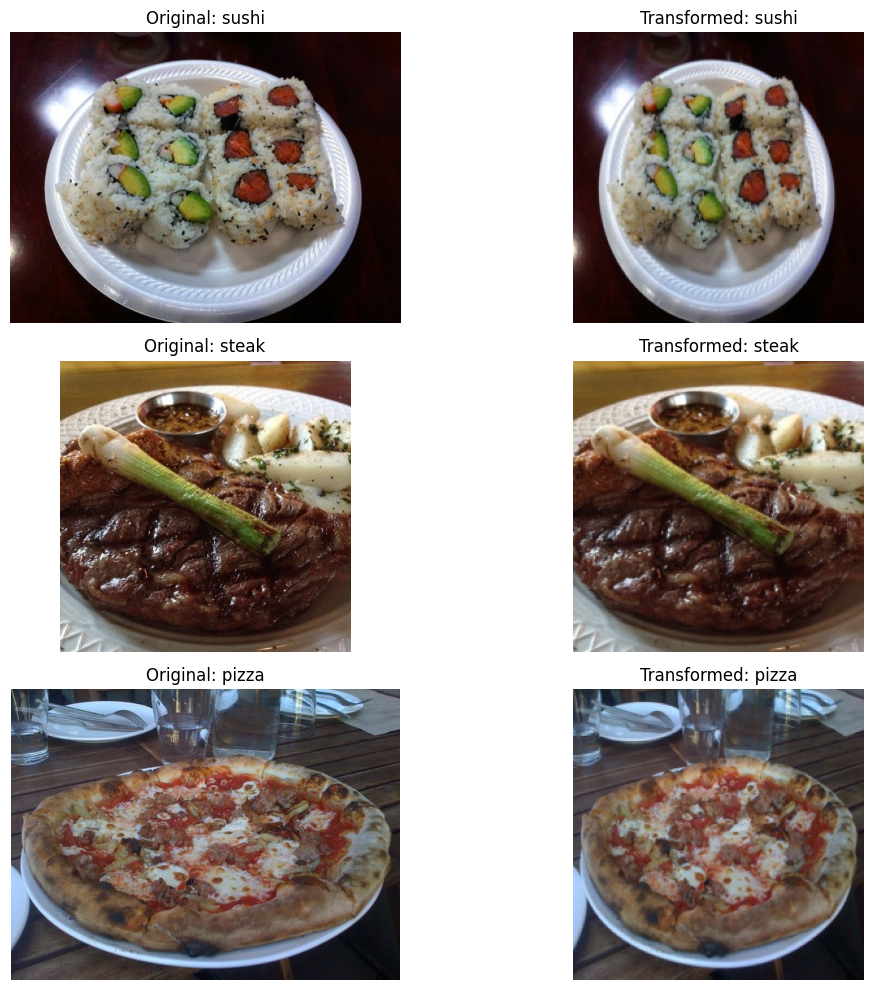

In [11]:
plot_transformed_images(image_path_list, transform=img_transform)

## 4. Loading Images using `datasets.ImageFolder`

In [12]:
from torch.utils.data import DataLoader
from torchvision import datasets
import os

num_workers = os.cpu_count()
print(f"Num workers: {num_workers}")

train_dataset = datasets.ImageFolder(
    root=train_path,
    transform=img_transform, # a transform for the data
    target_transform=None # a transform for the target/label
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=Config.batch_size,
    shuffle=True,
    num_workers=num_workers
)

test_dataset = datasets.ImageFolder(
    root=test_path,
    transform=img_transform,
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=Config.batch_size,
    shuffle=False,
    num_workers=num_workers
)

Num workers: 2


In [13]:
# Get class names
class_names = train_dataset.classes
class_names

['pizza', 'steak', 'sushi']

## 5. Replicating the `datasets.ImageFolder`

In [14]:
from torch.utils.data import Dataset

class CustomImageFolder(Dataset):
  def __init__(self, directory, transform = None, *args, **kwargs):
    super().__init__(*args, **kwargs)
    if not Path(directory).exists():
      raise Exception(f"Directory: {directory} doesn't exist.")
    self.directory = Path(directory)
    self.transform = transform
    self.classes = self.get_classes_names()
    self.samples = self.get_samples()

  def get_classes_names(self):
    classes_names = []
    for dirpath, dirnames, filenames in os.walk(self.directory):
      if len(filenames) > 0:
        classes_names.append(Path(dirpath).stem)

    return sorted(classes_names)

  def get_samples(self):
    samples = []
    for dirpath, dirnames, filenames in os.walk(self.directory):
      for filename in filenames:
        full_img_path = Path(dirpath) / filename
        pil_img = Image.open(full_img_path)
        img_target = Path(dirpath).stem

        samples.append(
            [
                self.transform(pil_img) if self.transform else pil_img,
                self.class_to_idx()[img_target]
            ]
        )

    return samples

  def class_to_idx(self):
    return {class_name: i for i, class_name in enumerate(self.classes)}

  def __getitem__(self, idx):
    img, target = self.samples[idx]
    return img, target

  def __len__(self):
    return len(self.samples)


custom_train_dataset = CustomImageFolder(directory=train_path, transform=img_transform)
custom_test_dataset = CustomImageFolder(directory=test_path, transform=img_transform)

### 5.1 Testing our custom dataset

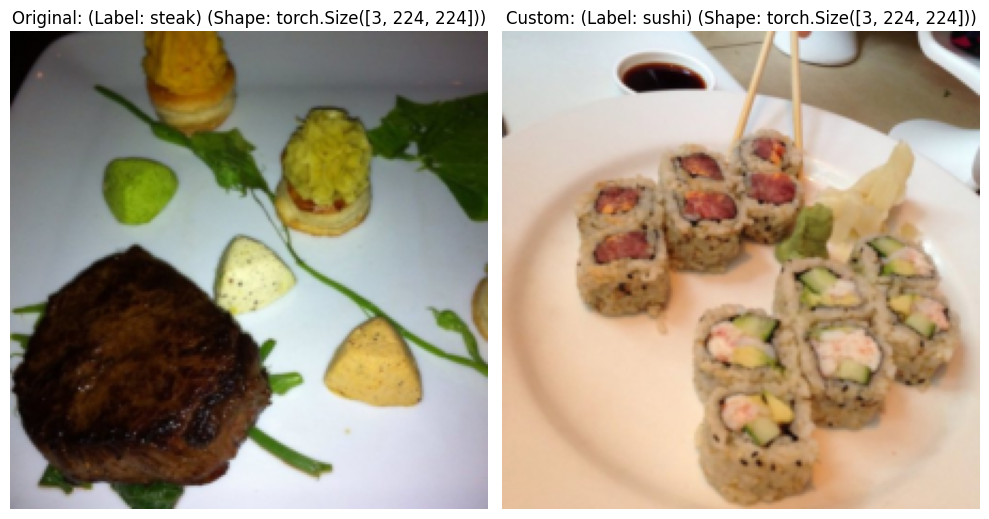

In [15]:
random_idx = random.choice(range(len(custom_test_dataset)))

custom_test_sample = custom_test_dataset[random_idx]
test_sample = test_dataset[random_idx]

fig, axes = plt.subplots(1, 2, figsize=(10, 7))

axes[0].imshow(test_sample[0].permute(1, 2, 0))
axes[0].set_title(f"Original: (Label: {class_names[test_sample[1]]}) (Shape: {test_sample[0].shape})")
axes[0].axis("off")

axes[1].imshow(custom_test_sample[0].permute(1, 2, 0))
axes[1].set_title(f"Custom: (Label: {custom_test_dataset.classes[custom_test_sample[1]]}) (Shape: {custom_test_sample[0].shape})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [16]:
custom_test_dataset.class_to_idx()

{'pizza': 0, 'steak': 1, 'sushi': 2}

### 5.1 - Creating our custom transforms

In [17]:
train_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.ToTensor()
])

custom_train_dataset = CustomImageFolder(
    directory=train_path,
    transform=train_transform
)

custom_test_dataset = CustomImageFolder(
    directory=test_path,
    transform=test_transform
)



### 5.2 - Creating Dataloaders from our custom datasets

In [18]:
train_dataloader = DataLoader(
    dataset=custom_train_dataset,
    batch_size=Config.batch_size,
    shuffle=True,
    num_workers=Config.num_workers
)

test_dataloader = DataLoader(
    dataset=custom_test_dataset,
    batch_size=Config.batch_size,
    shuffle=False,
    num_workers=Config.num_workers
)

## 6. Data Augmentation - (Data Augmentation is the process of artificially adding diversity to your training data)

## 6.1 - Trivial Augment

In [19]:
trivial_augment_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

In [20]:
class Utils:
  @staticmethod
  def pil_img_to_tensor(pil_img: Image.Image, transform, with_batch = False, device: torch.device | None = None):
    if not transform:
      raise Exception("Transform must to be defined")

    transformed_img = transform(pil_img)

    if device:
      transformed_img = transformed_img.to(device)

    return transformed_img.unsqueeze(dim=0) if with_batch else transformed_img

  @staticmethod
  def plot_random_img(img, target, transform = None):

    plt.figure(figsize=(16, 10))
    if transform:
      transformed_image = transform(img)
      display_image = transformed_image.permute(1, 2, 0).cpu().numpy()
    else:
      display_image = img

    plt.imshow(display_image)
    plt.title(target)
    plt.axis("off")
    plt.show()

  @staticmethod
  def get_all_images_paths(root_path):
    return list(Path(root_path).glob("*/*/*.jpg"))

  @staticmethod
  def get_image_and_target(img_path: Path):
    img = Image.open(img_path)
    target = img_path.parent.stem

    return img, target

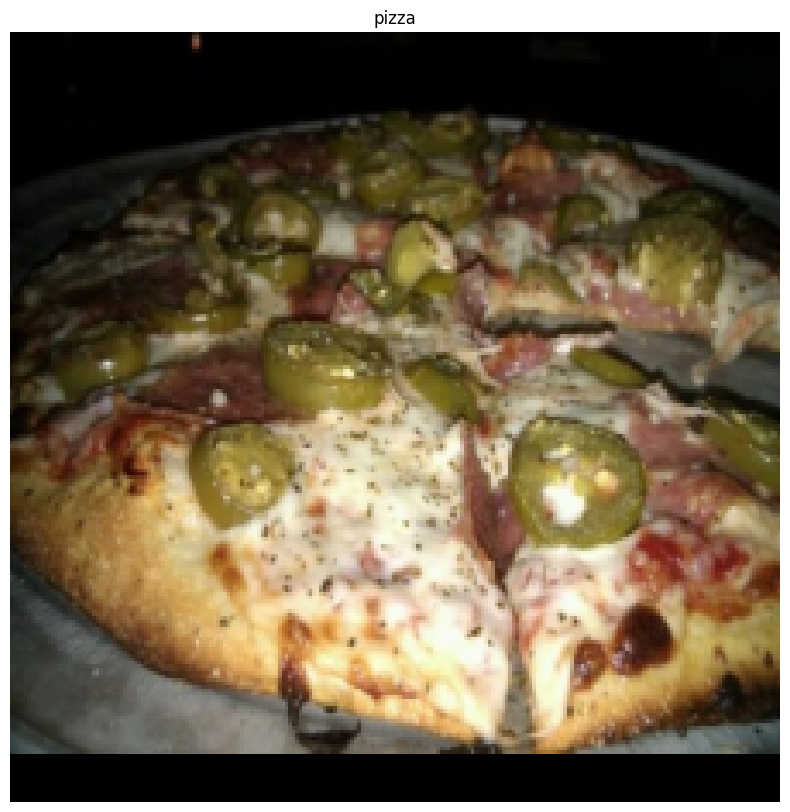

In [21]:
image_path_list = Utils.get_all_images_paths(images_path)
img, target = Utils.get_image_and_target(random.choice(image_path_list))
Utils.plot_random_img(img, target, transform=trivial_augment_transform)

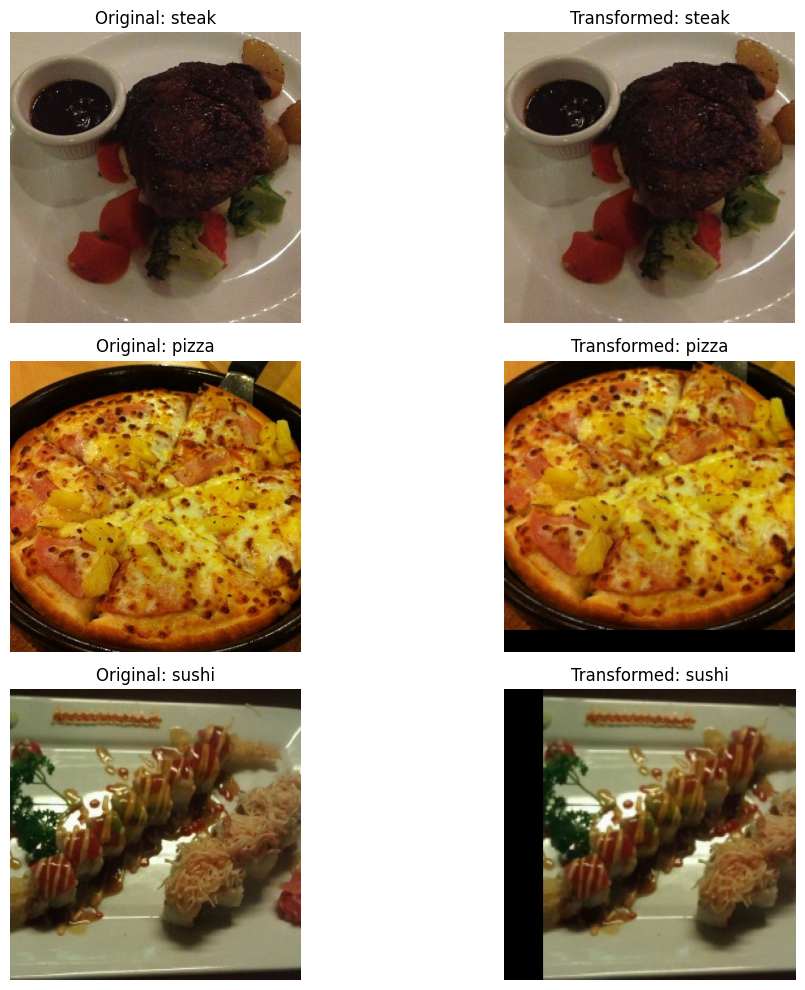

In [22]:
plot_transformed_images(image_path_list, transform=trivial_augment_transform, n=3)

## 7. Model 0: TinyVGG without data augmentation

### 7.1 - Creating transforms and loading data

In [23]:
tiny_vgg_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.ToTensor()
])

In [24]:
train_dataset = CustomImageFolder(
    directory=train_path,
    transform=tiny_vgg_transform
)

test_dataset = CustomImageFolder(
    directory=test_path,
    transform=tiny_vgg_transform
)

In [25]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=Config.batch_size,
    shuffle=True,
    num_workers=Config.num_workers
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=Config.batch_size,
    shuffle=False,
    num_workers=Config.num_workers
)

### 7.2 - Creating TinyVGG Model Class

In [26]:
class TinyVGG(nn.Module):
  def __init__(
      self,
      input_shape: int,
      output_shape: int,
      hidden_units: int
  ):
    super().__init__()

    # for each dimension: output = floor((input + 2 * padding − kernel_size) / stride) + 1

    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(
            in_channels=input_shape,
            out_channels=hidden_units,
            kernel_size=3,
            stride=1,
            padding=1
        ),
        nn.ReLU(),
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units,
            kernel_size=3,
            stride=1,
            padding=1
        ),
        nn.ReLU(),
        nn.MaxPool2d(
            kernel_size=2
        )
    )

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units,
            kernel_size=3,
            stride=1,
            padding=1
        ),
        nn.ReLU(),
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units,
            kernel_size=3,
            stride=1,
            padding=1
        ),
        nn.ReLU(),
        nn.MaxPool2d(
            kernel_size=2
        )
    )

    self.classifier = nn.Sequential(
        nn.AdaptiveAvgPool2d((1, 1)),
        nn.Flatten(),
        nn.Linear(hidden_units, output_shape)
    )

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.classifier(self.conv_block_2(self.conv_block_1(x)))


In [27]:
class_names = train_dataset.classes
torch.manual_seed(42)

tinyvgg_model = TinyVGG(
    input_shape=Config.num_color_channels, # Number of color_channels
    output_shape=len(class_names), # Number of classes
    hidden_units=128
).to(Config.device)

tinyvgg_model

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=128, out_features=3, bias=True)
  )
)

### 7.3 - Try a forward pass in a single image

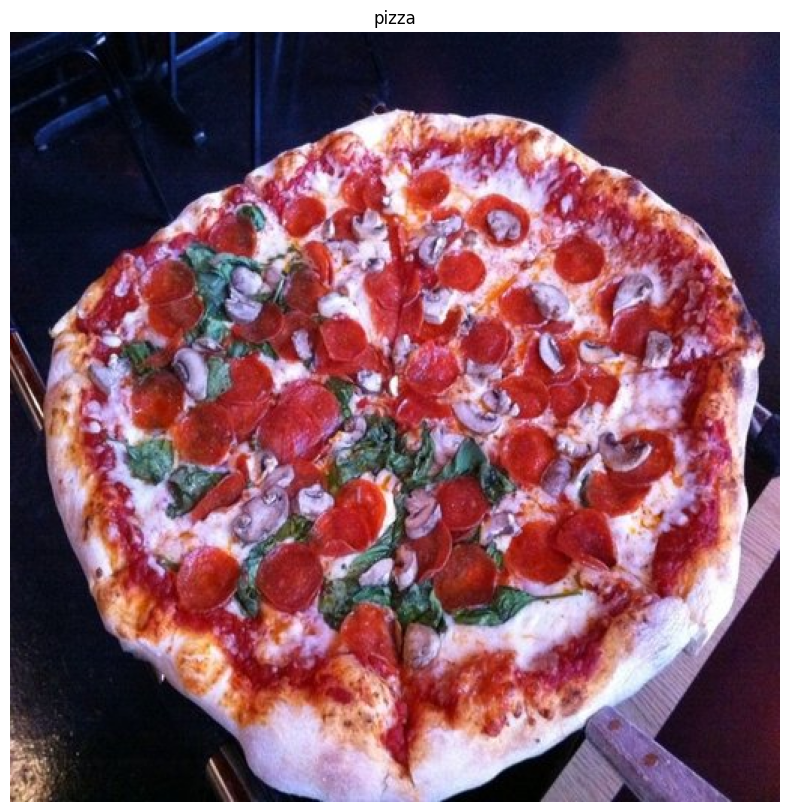

In [28]:
all_paths = Utils.get_all_images_paths(images_path)
img, target = Utils.get_image_and_target(random.choice(all_paths))

Utils.plot_random_img(img, target)

In [29]:
tensor_img = Utils.pil_img_to_tensor(img, transform=tiny_vgg_transform, with_batch=True, device=Config.device)
print(tensor_img.shape)


with torch.inference_mode():
  tinyvgg_model.eval()
  y_logits = tinyvgg_model(tensor_img)
  y_probs = torch.softmax(y_logits, dim=1)
  y_prediction = torch.argmax(y_probs, dim=1)
  print(f"True label: {target} | Predicted label: {class_names[y_prediction]}")

torch.Size([1, 3, 224, 224])
True label: pizza | Predicted label: steak


### 7.4 - Using `torchinfo` to get informations about our model

In [30]:
!pip install torchinfo

In [31]:
from torchinfo import summary

summary(tinyvgg_model, input_size=[1, 3, 224, 224])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 128, 112, 112]        --
│    └─Conv2d: 2-1                       [1, 128, 224, 224]        3,584
│    └─ReLU: 2-2                         [1, 128, 224, 224]        --
│    └─Conv2d: 2-3                       [1, 128, 224, 224]        147,584
│    └─ReLU: 2-4                         [1, 128, 224, 224]        --
│    └─MaxPool2d: 2-5                    [1, 128, 112, 112]        --
├─Sequential: 1-2                        [1, 128, 56, 56]          --
│    └─Conv2d: 2-6                       [1, 128, 112, 112]        147,584
│    └─ReLU: 2-7                         [1, 128, 112, 112]        --
│    └─Conv2d: 2-8                       [1, 128, 112, 112]        147,584
│    └─ReLU: 2-9                         [1, 128, 112, 112]        --
│    └─MaxPool2d: 2-10                   [1, 128, 56, 56]          

### 7.5 - Creating our testing and training functions

In [32]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 26.6 MB/s eta 0:00:00


In [33]:
from torchmetrics.classification import Accuracy

In [34]:
class ModelOperator:
  def __init__(
      self,
      model: nn.Module,
      loss_fn: nn.Module,
      optimizer: torch.optim.Optimizer,
      device: torch.device,
      accuracy_fn: Accuracy | None = None
  ):
    self.model = model.to(device)
    self.loss_fn = loss_fn
    self.optimizer = optimizer
    self.device = device
    self.accuracy_fn = accuracy_fn.to(device)


  def test_step(self, test_dataloader: DataLoader):
    loss_value = 0
    self.accuracy_fn.reset()
    self.model.eval()
    with torch.inference_mode():
      for i, (X, y) in enumerate(test_dataloader):
        X = X.to(self.device)
        y = y.to(self.device)
        y_logits = self.model(X)
        y_probs = torch.softmax(y_logits, dim=1)
        y_predictions = torch.argmax(y_probs, dim=1)

        loss_value += self.loss_fn(y_logits, y).item()
        self.accuracy_fn.update(y_predictions, y)

    loss_avg = loss_value / len(test_dataloader)
    final_accuracy = self.accuracy_fn.compute()
    print(f"Test Loss: {loss_avg} | Test Accuracy: {final_accuracy * 100:.4f}%")

  def train_step(self, train_dataloader: DataLoader):
    loss_value = 0
    self.accuracy_fn.reset()
    self.model.train()

    for i, (X, y) in enumerate(train_dataloader):
      X = X.to(self.device)
      y = y.to(self.device)
      # 1. Forward pass
      y_logits = self.model(X)
      y_probs = torch.softmax(y_logits, dim=1)
      y_predictions = torch.argmax(y_probs, dim=1)

      # 2. Calculate the Loss / Accuracy
      loss = self.loss_fn(y_logits, y)
      self.accuracy_fn.update(y_predictions, y)
      loss_value += loss.item()

      # 3. Zero Grad
      self.optimizer.zero_grad()

      # 4. Perform Backpropagation
      loss.backward()

      # 5. Optimizer step
      self.optimizer.step()

    loss_avg = loss_value / len(train_dataloader)
    final_accuracy = self.accuracy_fn.compute()
    print(f"Train Loss: {loss_avg} | Train Accuracy: {final_accuracy * 100:.4f}%")





In [35]:
model_operator = ModelOperator(
    model=tinyvgg_model,
    loss_fn=nn.CrossEntropyLoss(),
    optimizer=torch.optim.Adam(params=tinyvgg_model.parameters(), lr=0.0001),
    device=Config.device,
    accuracy_fn=Accuracy(task="multiclass", num_classes=len(class_names)),
)

In [36]:
from tqdm import tqdm

In [37]:
for epoch in tqdm(range(50)):
  model_operator.train_step(train_dataloader)
  model_operator.test_step(test_dataloader)

  0%|          | 0/50 [00:00<?, ?it/s]

Train Loss: 1.1144630014896393 | Train Accuracy: 32.8889%


  2%|▏         | 1/50 [00:03<03:09,  3.87s/it]

Test Loss: 1.09148375193278 | Test Accuracy: 33.3333%
Train Loss: 1.1071099936962128 | Train Accuracy: 34.6667%


  4%|▍         | 2/50 [00:07<02:58,  3.71s/it]

...

Test Loss: 1.2180025577545166 | Test Accuracy: 46.6667%
Train Loss: 0.881668284535408 | Train Accuracy: 61.7778%


 98%|█████████▊| 49/50 [02:44<00:03,  3.45s/it]

Test Loss: 1.2315998276074727 | Test Accuracy: 45.3333%
Train Loss: 0.8290266171097755 | Train Accuracy: 62.6667%


100%|██████████| 50/50 [02:48<00:00,  3.37s/it]

Test Loss: 1.1093942523002625 | Test Accuracy: 42.6667%


In [38]:
# Our Model is Overfitting

## 8. How to deal with overfitting

### 8.1 - Data Augmentation

In [40]:
# Create a Transform with data augmentation
train_transform_trivial = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.ToTensor()
])

In [41]:
train_augmented_dataset = datasets.ImageFolder(
    root=train_path,
    transform=train_transform_trivial
)

test_simple_dataset = datasets.ImageFolder(
    root=test_path,
    transform=test_transform
)

In [43]:
torch.manual_seed(42)

train_augmented_dataloader = DataLoader(
    train_augmented_dataset,
    batch_size=Config.batch_size,
    shuffle=True,
    num_workers=Config.num_workers
)

test_dataloader = DataLoader(
    test_simple_dataset,
    batch_size=Config.batch_size,
    shuffle=False,
    num_workers=Config.num_workers
)

In [44]:
class_names = train_augmented_dataset.classes

In [46]:
torch.manual_seed(42)

model_1_augmented = TinyVGG(
    input_shape=3,
    output_shape=len(class_names),
    hidden_units=128
)

In [49]:
model_1_operator = ModelOperator(
    model=model_1_augmented,
    loss_fn=nn.CrossEntropyLoss(),
    optimizer=torch.optim.Adam(params=model_1_augmented.parameters(), lr=0.0001),
    device=Config.device,
    accuracy_fn=Accuracy(task='multiclass', num_classes=len(class_names))
)

In [50]:
for epoch in tqdm(range(1000)):
  model_1_operator.train_step(
      train_augmented_dataloader
  )

  model_1_operator.test_step(test_dataloader)

  0%|          | 0/1000 [00:00<?, ?it/s]

Train Loss: 1.02877027541399 | Train Accuracy: 56.4444%


  0%|          | 1/1000 [00:03<1:02:17,  3.74s/it]

Test Loss: 1.028961976369222 | Test Accuracy: 46.6667%
Train Loss: 0.9282372482120991 | Train Accuracy: 57.7778%


  0%|          | 2/1000 [00:07<1:01:44,  3.71s/it]

...

Test Loss: 0.9246575832366943 | Test Accuracy: 60.0000%
Train Loss: 0.6439966335892677 | Train Accuracy: 74.2222%


100%|█████████▉| 999/1000 [1:04:00<00:03,  3.81s/it]

Test Loss: 0.8855340480804443 | Test Accuracy: 58.6667%
Train Loss: 0.6357336714863777 | Train Accuracy: 80.4444%


100%|██████████| 1000/1000 [1:04:04<00:00,  3.84s/it]

Test Loss: 0.8567108511924744 | Test Accuracy: 62.6667%
